In [1]:
!pip install -q --no-cache-dir --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git@main

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aeroguard.sequences import creer_dataset, decouper_fenetres, extraire_fenetres

DOSSIER = "/content/drive/MyDrive/aeroguard"
archive_fenetres = np.load(f"{DOSSIER}/data/processed/fenetres_v4.npz")
donnees = {cle: archive_fenetres[cle] for cle in archive_fenetres.files}
infos = pd.read_parquet(f"{DOSSIER}/data/processed/fenetres_v4_infos.parquet")
CANAUX = list(donnees["canaux"])
LONGUEUR_FENETRE = donnees["X_train"].shape[1]
masques = {groupe: (infos["groupe"] == groupe).to_numpy() for groupe in ("train", "val", "test")}

print("Canaux :", len(CANAUX), CANAUX)
print("Longueur d'une fenêtre :", LONGUEUR_FENETRE, "secondes")
for groupe in ("train", "val", "test"):
    print(f"{groupe:5s} : X {donnees[f'X_{groupe}'].shape}, y {donnees[f'y_{groupe}'].shape}")

Mounted at /content/drive
Canaux : 18 [np.str_('T24'), np.str_('T30'), np.str_('T48'), np.str_('T50'), np.str_('P15'), np.str_('P2'), np.str_('P21'), np.str_('P24'), np.str_('Ps30'), np.str_('P40'), np.str_('P50'), np.str_('Nf'), np.str_('Nc'), np.str_('Wf'), np.str_('alt'), np.str_('Mach'), np.str_('TRA'), np.str_('T2')]
Longueur d'une fenêtre : 256 secondes
train : X (14864, 256, 18), y (14864,)
val   : X (3276, 256, 18), y (3276,)
test  : X (11752, 256, 18), y (11752,)


In [3]:
signal_jouet = np.arange(20).reshape(10, 2)        # 10 secondes, 2 canaux
for pas in (1, 2, 4):
    fenetres = decouper_fenetres(signal_jouet, longueur=4, pas=pas)
    debuts = [int(fenetre[0, 0]) // 2 for fenetre in fenetres]
    print(f"pas = {pas} → forme {fenetres.shape}, débuts des fenêtres : {debuts}")

fenetres_regulieres = extraire_fenetres(signal_jouet, longueur=4, nombre=3)
print("3 fenêtres régulières → débuts :", [int(f[0, 0]) // 2 for f in fenetres_regulieres])

pas = 1 → forme (7, 4, 2), débuts des fenêtres : [0, 1, 2, 3, 4, 5, 6]
pas = 2 → forme (4, 4, 2), débuts des fenêtres : [0, 2, 4, 6]
pas = 4 → forme (2, 4, 2), débuts des fenêtres : [0, 4]
3 fenêtres régulières → débuts : [0, 3, 6]


In [4]:
print(infos.groupby("groupe").agg(fenetres=("moteur", "size"),
                                   moteurs=("moteur", "nunique"),
                                   part_usure=("usure", "mean")).round(3))

memoire_actuelle = sum(donnees[f"X_{g}"].nbytes for g in ("train", "val", "test"))
nombre_fenetres = sum(len(donnees[f"X_{g}"]) for g in ("train", "val", "test"))
print(f"\nFenêtres : {nombre_fenetres:,} → mémoire : {memoire_actuelle / 1e9:.2f} Go")

# Estimation avec un pas de 1 (une fenêtre par seconde de vol)
# DS01 : 7 641 868 secondes pour 894 vols (mesuré dans ton premier essai)
secondes_par_vol = 7_641_868 / 894
nombre_vols = infos.groupby(["moteur", "cycle"]).ngroups
fenetres_pas_de_1 = nombre_vols * (secondes_par_vol - LONGUEUR_FENETRE + 1)
octets_par_fenetre = LONGUEUR_FENETRE * len(CANAUX) * 4
print(f"Avec un pas de 1 : ≈ {fenetres_pas_de_1 / 1e6:.0f} millions de fenêtres "
      f"→ ≈ {fenetres_pas_de_1 * octets_par_fenetre / 1e12:.1f} To")

        fenetres  moteurs  part_usure
groupe                               
test       11752       39       0.678
train      14864       49       0.705
val         3276       11       0.702

Fenêtres : 29,892 → mémoire : 0.55 Go
Avec un pas de 1 : ≈ 62 millions de fenêtres → ≈ 1.1 To


In [5]:
TAILLE_LOT = 256
dataset_train = creer_dataset(donnees["X_train"], donnees["y_train"], taille_lot=TAILLE_LOT)
dataset_val = creer_dataset(donnees["X_val"], donnees["y_val"], taille_lot=TAILLE_LOT, melanger=False)

for lot_X, lot_y in dataset_train.take(1):
    print("Forme d'un lot X :", lot_X.shape)
    print("Forme d'un lot y :", lot_y.shape)
    print("Part de fenêtres usées dans ce lot :", round(float(lot_y.numpy().mean()), 3))

nombre_lots = int(np.ceil(len(donnees["X_train"]) / TAILLE_LOT))
print("Lots par époque (train) :", nombre_lots)

Forme d'un lot X : (256, 256, 18)
Forme d'un lot y : (256,)
Part de fenêtres usées dans ce lot : 0.746
Lots par époque (train) : 59


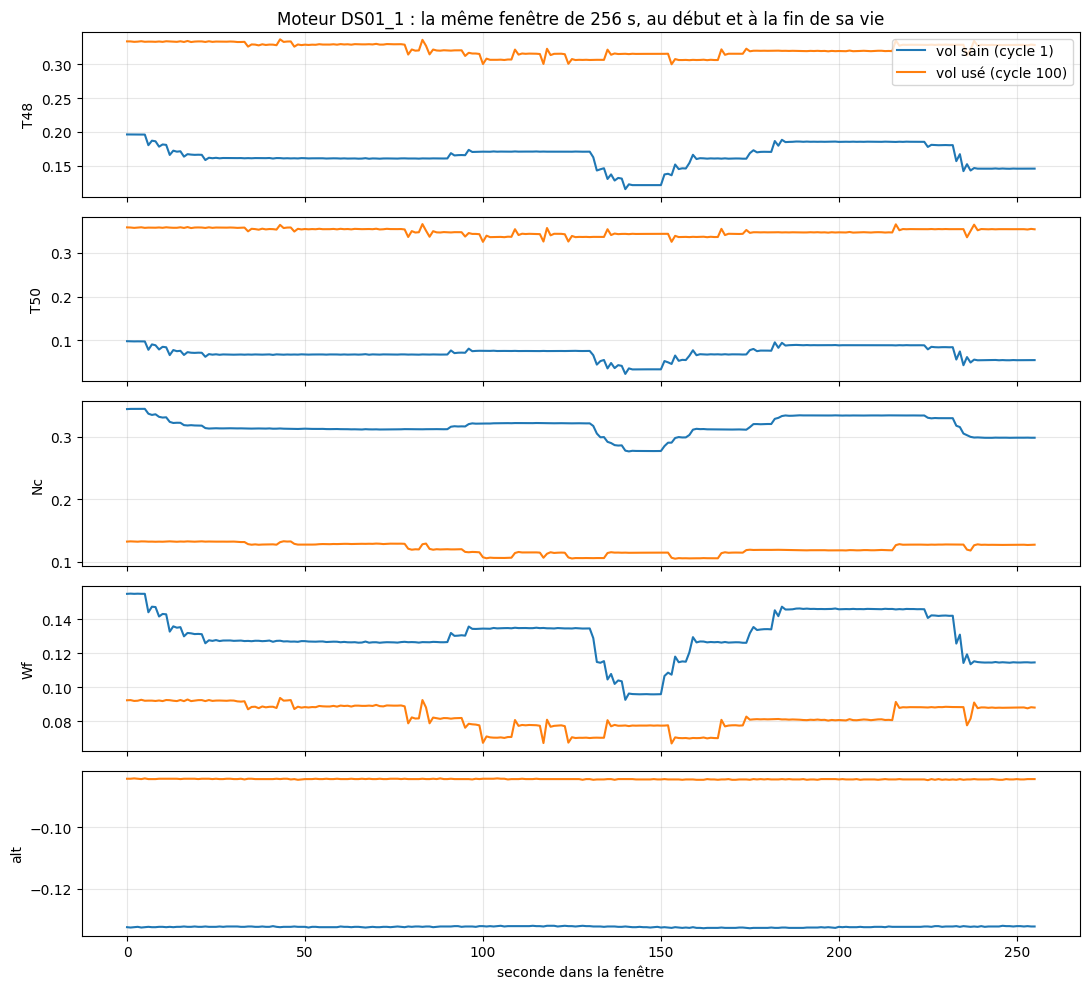

In [6]:
infos_val = infos[masques["val"]].reset_index(drop=True)
moteur_exemple = infos_val["moteur"].iloc[0]
lignes_moteur = infos_val[infos_val["moteur"] == moteur_exemple]
POSITION = 1                                                    # 2e fenêtre de chaque vol
indice_sain = lignes_moteur[(lignes_moteur["usure"] == 0) & (lignes_moteur["position"] == POSITION)].index[0]
indice_use = lignes_moteur[(lignes_moteur["usure"] == 1) & (lignes_moteur["position"] == POSITION)].index[-1]

canaux_affiches = ["T48", "T50", "Nc", "Wf", "alt"]
figure, axes = plt.subplots(len(canaux_affiches), 1, figsize=(11, 10), sharex=True)
for axe, canal in zip(axes, canaux_affiches):
    colonne = CANAUX.index(canal)
    axe.plot(donnees["X_val"][indice_sain, :, colonne],
             label=f"vol sain (cycle {infos_val.loc[indice_sain, 'cycle']})")
    axe.plot(donnees["X_val"][indice_use, :, colonne],
             label=f"vol usé (cycle {infos_val.loc[indice_use, 'cycle']})")
    axe.set_ylabel(canal)
    axe.grid(alpha=0.3)
axes[0].legend(loc="upper right")
axes[0].set_title(f"Moteur {moteur_exemple} : la même fenêtre de 256 s, au début et à la fin de sa vie")
axes[-1].set_xlabel("seconde dans la fenêtre")
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/45_fenetre_saine_usee.png", dpi=150)
plt.show()